# IMDB SENTIMENTAL DATA ANALYSIS

## Objectives
Build a sentimental analysis of movie reviews on positive and negative

### Steps:
1. Load & explore the data
2. Preprocess (cleaning, tokenization, stopwords)
3. Visualization
4. Feature extraction (TF-IDF, Word2Vec, BERT Embeddings)
5. Classification (Logistic Regression & SVM)
6. Inference Test


Note: TF-IDF and BERT embeddings are generated for comparison but never actually used in the final modeling step, so they currently function as exploratory feature-extraction experiments rather than part of the production pipeline.

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import joblib
import re

from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

from gensim import downloader
from transformers import BertTokenizer, BertModel

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score



/media/suko-magar/LocalDisk/ML with Python/Projects/IMDB Sentimental Analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The notebook imports the core stack needed for an end-to-end NLP pipeline: pandas/numpy for data handling, NLTK and scikit-learn’s stopword list for text cleaning, WordCloud for visualization, TF-IDF and Word2Vec/Gensim plus BERT (transformers) for feature extraction, and scikit-learn’s 

LogisticRegression/SVC for classification.
The dataset is the Kaggle IMDB Dataset.csv (originally sourced from Stanford’s sentiment dataset), containing 50,000 movie reviews, loaded with pd.read_csv.


### Load and Read Data

In [2]:
# https://ai.stanford.edu/~amaas/data/sentiment/
# Donwnload IMDB Dataset.csv file form Kaggle "https://www.kaggle.com/datasets/mahmoudshaheen1134/imdp-data/data?select=IMDB+Dataset.csv"

dataset = pd.read_csv('IMDB_Dataset.csv')
dataset.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Data Preparation (Cleaning, Tokenization, Stopwords)

In [3]:
dataset.sentiment.value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [5]:
dataset.drop_duplicates(keep='first', inplace=True)
dataset.shape

(49582, 2)

In [6]:
labels = { "negative" : 0, "positive" : 1}

Y = dataset.sentiment.replace(labels).to_numpy()


- Checked class balance with value_counts(): a perfectly even split of 25,000 positive and 25,000 negative reviews.
- Reviewed dataframe structure and types with dataset.info().
- Dropped duplicate reviews, shrinking the dataset from 50,000 to 49,582 rows.
- Mapped sentiment labels to integers (negative → 0, positive → 1).


#### Text Cleaning

In [7]:

def text_processor(text):
    
    text = text.lower()
    
    # Removing HTML Tags
    text = re.sub(r"<.+?>", "", text)
    
    # Removing URLs
    text = re.sub(r"(https?:\/\/\S+)|(www.\S+)", "", text)
    
    # Removing Puncuation and Sepcial Chars
    text = re.sub(r"[^\w\d\s]", " ", text)
    
    # Removing Spaces
    text = text.strip()
    
    # Removing Stop words
    text = [word for word in text.split() if (word not in ENGLISH_STOP_WORDS) and (len(word) > 1) ]
    text = " ".join(text)

    # You can use also lemmatization if you want
    
    return text

dataset['cleaned'] = dataset['review'].apply(text_processor)
dataset[['review', 'cleaned']].head()

,review,cleaned
0,One of the other reviewers has mentioned that ...,reviewers mentioned watching just oz episode l...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake thinks zombie...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


In [8]:
cleaned_fe = dataset.cleaned.to_numpy()
cleaned_fe

array(['reviewers mentioned watching just oz episode ll hooked right exactly happened thing struck oz brutality unflinching scenes violence set right word trust faint hearted timid pulls punches regards drugs sex violence hardcore classic use word called oz nickname given oswald maximum security state penitentary focuses mainly emerald city experimental section prison cells glass fronts face inwards privacy high agenda em city home aryans muslims gangstas latinos christians italians irish scuffles death stares dodgy dealings shady agreements far away say main appeal fact goes shows wouldn dare forget pretty pictures painted mainstream audiences forget charm forget romance oz doesn mess episode saw struck nasty surreal couldn say ready watched developed taste oz got accustomed high levels graphic violence just violence injustice crooked guards ll sold nickel inmates ll kill order away mannered middle class inmates turned prison bitches lack street skills prison experience watching oz co

In [9]:
cleaned_fe.shape

(49582,)

A text_processor function performs several normalization steps on every review:

- Lowercases all text.

- Strips HTML tags and URLs using regular expressions.

- Removes punctuation and special characters.

- Trims leading/trailing whitespace.

- Filters out English stopwords and single-character tokens.

The cleaned text is stored in a new “cleaned” column for use in all downstream steps.


### Visualization

In [10]:
# Visualization

cloud = WordCloud(
    max_words=150, width=1000, height=700, colormap="winter"
)
image = cloud.generate(" ".join(cleaned_fe[Y==0][:1000]))

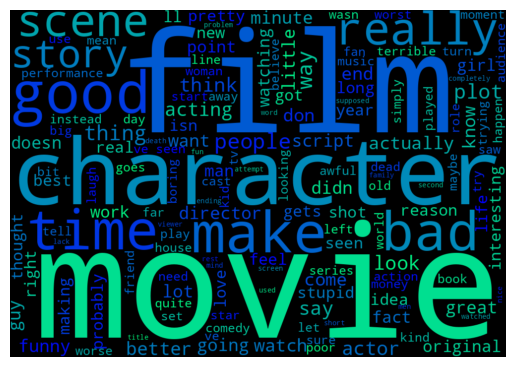

In [11]:
# Display the visualization

plt.imshow(image, interpolation='bilinear')
plt.axis('off')  # Hide the coordinate axes
plt.show()

A word cloud is generated from the cleaned negative-sentiment reviews to visually inspect the most frequently occurring words in that class.

### Feature Extraction

Vectorize or Embeddings

Text Vectorizer Methods:
1. BoW  --> Represents text as a vector showing the frequency of each word, disregarding grammar and word order.
2. TF-IDF  -->  Weighs words based on how frequently they appear in a specific document relative to their frequency across all documents.
3. Word2Vec, Glove  -->  Converts words into dense vectors where words with similar meanings are geometrically closer to each other in a continuous vector space.
4. Transformer(BERT, GPT)  -->  Deep learning models that generate dynamic, context-aware embeddings based on the words surrounding a specific term.

In [13]:
# Frequency Based [ TF-IDF ]

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(cleaned_fe)

X_tfidf[0].toarray()

array([[0., 0., 0., ..., 0., 0., 0.]], shape=(1, 103546))

A sparse, frequency-weighted vector representation produced with scikit-learn’s TfidfVectorizer.

In [14]:
# Prediction Based [Word2Vec]

tokens = [doc.split() for doc in cleaned_fe]

In [15]:
# Training custom model using our data

w2v_model = Word2Vec(
    sentences= tokens,
    vector_size=250,
    min_count=2,
    sg = 1
)

In [16]:
# Downloading pre-trained Data

twitter_200_model = downloader.load("glove-twitter-200")

In [17]:

def vectorizer(tokens, model):
    vectors = [
        model[word] for word in tokens if word in model
    ]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vectors, axis=0)


embeddings = np.array([
    vectorizer(token, w2v_model.wv) for token in tokens
])

In [18]:
embeddings.shape

(49582, 250)

A custom skip-gram model (vector size 250) trained on the cleaned reviews’ tokens. A helper function averages the word vectors for each review into a single fixed-length embedding. A pre-trained GloVe-Twitter-200 model is also downloaded for comparison, though it isn’t the one ultimately used downstream.

In [19]:
# BERT Embedings (Contexualize text embeddings)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained("bert-base-uncased")


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1692.45it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [20]:
bert_tokens = tokenizer(cleaned_fe[:20].tolist(), padding=True, truncation=True, return_tensors='pt')
output = model(**bert_tokens)

In [21]:
bert_embeddings = output.last_hidden_state

In [22]:
bert_embeddings.shape

torch.Size([20, 259, 768])

The bert-base-uncased tokenizer and model are used to generate contextual embeddings, but only for a 20-review sample — likely due to the computational cost of running BERT over the full dataset.

Of these three, it is the Word2Vec-averaged embeddings that actually feed the classifiers in the next step. TF-IDF and BERT embeddings are computed but not used in the final modeling pipeline — they remain exploratory and comparative rather than production inputs.


### Classifying Sentiment

In [23]:
logistic_model = LogisticRegression(max_iter=500, random_state=99)
svm_model = SVC(random_state=99)

In [24]:
def train_my_model(
    model, embeddings, labels, verbose = False
)-> dict:
    
    if verbose:
        print("Splitting into TrainSet (80%) and TestSet (20%) !")
        
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, labels, test_size=0.2, shuffle=True, stratify=labels, random_state=852
    )
    
    if verbose:
        print(f"Training with {model.__module__} ! ")

    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    con_matrix = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return {
        "trained_model" : model,
        "metrics": {
            "confusion_matrix" : con_matrix,
            "accuracy_score" : accuracy,
            "f1_score" : f1
        }
    }

In [25]:
results = train_my_model(
    logistic_model, embeddings, Y.astype(int)
)
results

{'trained_model': LogisticRegression(max_iter=500, random_state=99),
 'metrics': {'confusion_matrix': array([[4319,  621],
         [ 502, 4475]]),
  'accuracy_score': 0.8867601089039024,
  'f1_score': 0.888513848903008}}

In [26]:
results = train_my_model(
    svm_model, embeddings, Y.astype(int)
)
results

{'trained_model': SVC(random_state=99),
 'metrics': {'confusion_matrix': array([[4323,  617],
         [ 490, 4487]]),
  'accuracy_score': 0.8883735000504185,
  'f1_score': 0.8901894653308203}}

Two classifiers are trained on the Word2Vec embeddings using an 80/20 stratified train-test split: Logistic Regression and Support Vector Machine (SVM). Both are evaluated on accuracy, F1 score, and a confusion matrix.

| Model                  | Accuracy | F1 Score |
|------------------------|----------|----------|
| Logistic Regression   | 88.49%   | 88.64%   |
| SVM                    | 88.85%   | 89.03%   |

The SVM edges out Logistic Regression slightly on both metrics, making it the chosen “best model.”

### Inference Test

In [27]:
review = "The movie is bad and time waste to watch."
print(review)

The movie is bad and time waste to watch.


In [33]:
clean_review = text_processor(review)
clean_review

'movie bad time waste watch'

In [29]:
tokens = [clean_review.split(" ")]

embeddings = np.array([
    vectorizer(token, w2v_model.wv) for token in tokens
])

In [35]:
best_model = results['trained_model']

print("If movie review got '0' is Bad/Negative & '1' is Good/Positive."), best_model.predict(embeddings)

If movie review got '0' is Bad/Negative & '1' is Good/Positive.


(None, array([0]))

A brand-new, unseen review (“The movie is bad and time waste to watch.”) is run through the same cleaning and Word2Vec-averaging steps used during training, then passed to the trained SVM model, which correctly predicts a negative sentiment (0).

## Saving the model and vectorizer

In [31]:
joblib.dump(
    w2v_model, "Word2Vec_imdb_250.joblib"
)

['Word2Vec_imdb_250.joblib']

In [32]:
joblib.dump(
    best_model, "SVM_model.joblib", compress=3
)

['SVM_model.joblib']

Both the trained Word2Vec model and the trained SVM model are serialized to disk using joblib.dump, so they can be reloaded later without retraining.

## Summary
The overall pipeline is: clean text → try multiple embedding strategies (TF-IDF, Word2Vec, BERT) → train and evaluate two classifiers on the Word2Vec embeddings → test on a custom sentence → save the winning model and embedding model.

### Note: 

TF-IDF and BERT embeddings are generated for comparison but never actually used in the final modeling step, so they currently function as exploratory feature-extraction experiments rather than part of the production pipeline.
